In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF

In [2]:
model_type = 'lda' # or 'nmf'
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
PARA = OHCO[:3]
CHAP = OHCO[:2]
BOOK = OHCO[:1]
BAG = CHAP

In [20]:
TOKENS = pd.read_csv('Data\CORPUS\FULL_CORPUS.csv').set_index(OHCO).dropna(subset=['pos_group'])
TOKENS.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\school\AppData\Local\Temp\ipykernel_23636\3793211293.py:1: SyntaxWarning: invalid escape sequence '\C'
  TOKENS = pd.read_csv('Data\CORPUS\FULL_CORPUS.csv').set_index(OHCO).dropna(subset=['pos_group'])
C:\Users\school\AppData\Local\Temp\ipykernel_23636\3793211293.py:1: DtypeWarning: Columns (5,6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  TOKENS = pd.read_csv('Data\CORPUS\FULL_CORPUS.csv').set_index(OHCO).dropna(subset=['pos_group'])


pos_tuple  pos token_str  \
book_id chap_num para_num sent_num token_num                                    
3268    1        0        0        0            ('home', 'NN')   NN      home   
                                   1             ('is', 'VBZ')  VBZ        is   
                                   2             ('the', 'DT')   DT       the   
                                   3          ('resort', 'NN')   NN    resort   
                                   4              ('Of', 'IN')   IN        Of   

                                             term_str pos_group  
book_id chap_num para_num sent_num token_num                     
3268    1        0        0        0             home        NN  
                                   1               is        VB  
                                   2              the        DT  
                                   3           resort        NN  
                                   4               of        IN

In [87]:
DOCS = TOKENS[TOKENS.pos.str.match(r'^NNS?$')]\
    .groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

In [22]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS.union(['yes']))

In [23]:
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

absence  accents  accident  account  acquaintance  act  \
book_id  chap_num                                                           
175      1               0        0         2        0             0    0   
         2               2        0         0        0             0    0   
         3               0        0         0        0             1    0   
         4               0        0         0        1             0    3   
         5               0        1         0        0             0    0   
...                    ...      ...       ...      ...           ...  ...   
20180856 5               0        0         0        1             0    0   
         6               0        0         0        0             0    2   
         7               0        0         0        1             0    1   
         8               0        0         0        0             0    0   
         9               0        0         0        0             0    1   

                   action  admiration  advantage  advice  ...  works  world  \
book_id  chap_num                                         ...                 
175      1              0           0          0       0  ...      0      0   
         2              0           0          1       0  ...      1      1   
         3              0           0          0       0  ...      0      1   
         4              0           0          1       0  ...      0      0   
         5              2           0          0       0  ...      0      2   
...                   ...         ...        ...     ...  ...    ...    ...   
20180856 5              0           0          0       0  ...      0      4   
         6              0           0          0       0  ...      0      4   
         7              0           0          0       0  ...      0      2   
         8              0           0          0       0  ...      0      2   
         9              0           0          0       0  ...      0      1   

                   worth  wound  wretch  wretchedness  year  years  yesterday  \
book_id  chap_num                                                               
175      1             0      0       0             0     0      0          2   
         2             0      0       0             0     0      5          0   
         3             0      0       0             0     1      0          0   
         4             0      0       0             0     1      0          0   
         5             0      0       0             0     2      1          0   
...                  ...    ...     ...           ...   ...    ...        ...   
20180856 5             0      0       0             0     0      2          1   
         6             1      0       0             0     0      0          0   
         7             0      0       0             0     0      3          0   
         8             0      0       0             0     1      0          0   
         9             0      0       0             0     0      1          0   

                   youth  
book_id  chap_num         
175      1             0  
         2             0  
         3             0  
         4             0  
         5             0  
...                  ...  
20180856 5             0  
         6             0  
         7             0  
         8             0  
         9             0  

[85 rows x 963 columns]

In [24]:
n_topics = 20
max_iter = 100
n_top_terms = 9
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [25]:
if model_type == 'lda':
    topic_engine = LDA(n_components=n_topics, max_iter=max_iter)
elif model_type == 'nmf':
    topic_engine = NMF(n_components=n_topics, max_iter=max_iter)
topic_model = topic_engine.fit_transform(count_model)

# THETA

In [26]:
colors = "YlGnBu"
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

In [101]:
THETA.to_csv('Data/THETA.csv')

# PHI

In [27]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap=colors, axis=None)

term_str,images,fancy,dark,tear,movement,tonight,task,inn,garden,fatigue
topic_id,,,,,,,,,,
T00,0.050000,0.050000,0.050000,0.050000,7.173200,2.459600,0.050000,1.194692,1.142434,0.050000
T01,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,4.828424,0.050000
T02,6.003515,0.050000,9.469273,0.050000,0.050000,0.050000,2.995549,2.810562,10.758736,0.050000
T03,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T04,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T05,0.050000,0.050000,1.035174,0.050000,0.050000,2.046051,1.050000,0.050000,0.050000,0.050000
T06,1.050000,1.050000,1.107423,0.050000,1.116590,0.050000,0.050000,0.050000,0.050000,0.050000
T07,0.050000,1.085954,2.131952,2.826157,0.050000,4.842459,0.050000,0.050000,0.050000,0.050000
T08,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000


In [102]:
PHI.to_csv('Data/PHI.csv')


# TOPICS

In [28]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,ghost box voice managers letter pocket door no...
T01,house sister girl years family people road mot...
T02,moment voice life father words church child ro...
T03,path father heart mother mind days daughter mo...
T04,ghost managers death office story head mother ...
T05,door heart brother dressingroom voice room doc...
T06,forest room door viscount mirror sir water tre...
T07,voice room face door dressingroom love hand he...
T08,breast ease dread hell branch domestics friend...


In [29]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

,top_terms,doc_weight_sum,term_freq
topic_id,,,
T10,nan father son heart family friend apartment lord hand,10.865791,0.337721
T13,father tears mind moment aunt countenance heart grief subject,9.163282,0.100386
T18,doctor door house room hall night way head hand,8.446060,0.095389
T09,life misery death father heart happiness friend cousin fiend,7.166867,0.057435
T02,moment voice life father words church child room day,6.662142,0.090992
T00,ghost box voice managers letter pocket door notes thing,6.357033,0.034136
T11,st woods air road carriage night mind scene distance,5.823593,0.073557
T17,cottage night sun language wood day pleasure food place,5.029702,0.041236
T07,voice room face door dressingroom love hand head night,4.933467,0.025364


In [103]:
TOPICS.to_csv('Data/TOPICS.csv')


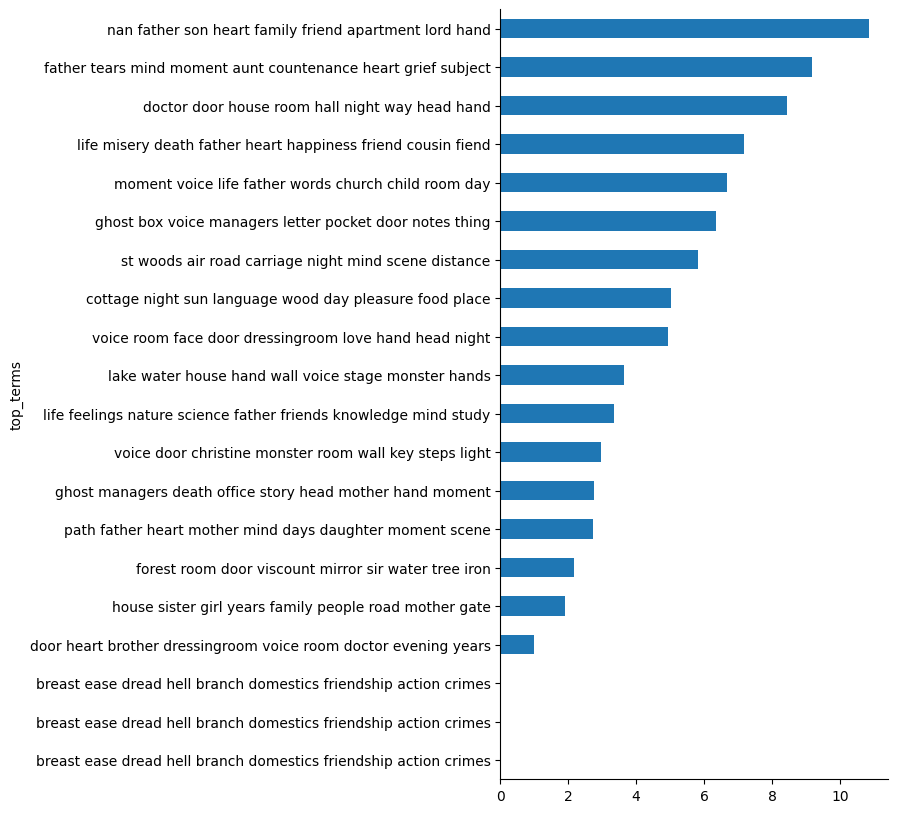

In [30]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

# TOPICS by LIB

In [62]:
LIB = pd.read_csv('Data/LIB.csv').set_index('book_id')
LIB.head()

,short_name,era,date,novel_type
book_id,,,,
43,jekyll,victorian,1886,thriller
41445,frankenstein,classic,1818,horror
175,phantom_of_the_opera,modern,1910,romance
345,dracula,victorian,1897,horror
696,otranto,high,1764,romance


In [63]:
THETAX = THETA.join(LIB).reset_index().set_index(['book_id','era','date','novel_type', 'short_name', 'chap_num'])
THETAX

T00  \
book_id  era    date novel_type short_name             chap_num             
175      modern 1910 romance    phantom_of_the_opera   1         0.295348   
                                                       2         0.000173   
                                                       3         0.000182   
                                                       4         0.929722   
                                                       5         0.038864   
...                                                                   ...   
20180856 modern 1959 thriller   haunting_of_hill_house 5         0.046059   
                                                       6         0.000136   
                                                       7         0.000073   
                                                       8         0.000115   
                                                       9         0.000106   

                                                                      T01  \
book_id  era    date novel_type short_name             chap_num             
175      modern 1910 romance    phantom_of_the_opera   1         0.000153   
                                                       2         0.000173   
                                                       3         0.000182   
                                                       4         0.000136   
                                                       5         0.056663   
...                                                                   ...   
20180856 modern 1959 thriller   haunting_of_hill_house 5         0.000074   
                                                       6         0.000136   
                                                       7         0.000073   
                                                       8         0.000115   
                                                       9         0.087204   

                                                                      T02  \
book_id  era    date novel_type short_name             chap_num             
175      modern 1910 romance    phantom_of_the_opera   1         0.033774   
                                                       2         0.000173   
                                                       3         0.000182   
                                                       4         0.000136   
                                                       5         0.531088   
...                                                                   ...   
20180856 modern 1959 thriller   haunting_of_hill_house 5         0.085357   
                                                       6         0.000136   
                                                       7         0.000073   
                                                       8         0.041674   
                                                       9         0.000106   

                                                                      T03  \
book_id  era    date novel_type short_name             chap_num             
175      modern 1910 romance    phantom_of_the_opera   1         0.000153   
                                                       2         0.000173   
                                                       3         0.000182   
                                                       4         0.067833   
                                                       5         0.000086   
...                                                                   ...   
20180856 modern 1959 thriller   haunting_of_hill_house 5         0.000074   
                                                       6         0.410050   
                                                       7         0.000073   
                                                       8         0.000115   
                                                       9         0.000106   

                                                              

# TOPICS by BOOK

In [64]:
TOPIC_BOOK = THETAX.groupby('book_id').mean() #.T.join(TOPICS[['top_terms','doc_weight_sum','term_freq']])
TOPIC_BOOK.T.style.background_gradient(axis=0, cmap="YlGnBu")

book_id,175,696,3268,5182,12122,41445,53685,20180856
T00,0.241475,0.000051,0.000093,0.000006,0.000339,0.000769,0.002357,0.005192
T01,0.004716,0.000051,0.000093,0.000006,0.000339,0.017664,0.021842,0.139328
T02,0.100494,0.078632,0.025128,0.000006,0.063950,0.038804,0.420154,0.016041
T03,0.013103,0.000051,0.000093,0.000006,0.000339,0.086542,0.000073,0.045629
T04,0.105295,0.000051,0.000093,0.000006,0.000339,0.000151,0.000073,0.000083
T05,0.038278,0.000051,0.000093,0.000006,0.000339,0.000151,0.000073,0.000083
T06,0.082681,0.000051,0.000093,0.000006,0.000339,0.000151,0.000073,0.000083
T07,0.120589,0.000051,0.000530,0.000006,0.567069,0.003856,0.000073,0.000083
T08,0.000212,0.000051,0.000093,0.000006,0.000339,0.000151,0.000073,0.000083
T09,0.002493,0.000051,0.002846,0.000006,0.000339,0.304194,0.010088,0.001875


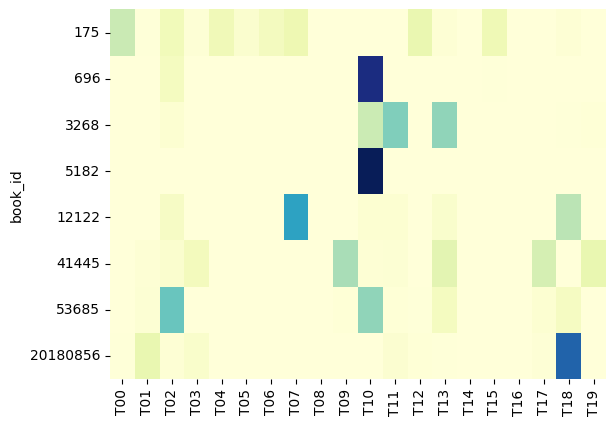

In [65]:
sns.heatmap(TOPIC_BOOK, cmap="YlGnBu", cbar=None)
plt.show()

# LDA + PCA

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD

In [67]:
pca_engine = PCA(n_components=5)
DCM = pd.DataFrame(pca_engine.fit_transform(THETA), index=THETA.index)
DCM.columns = ['PC{}'.format(i) for i in DCM.columns]
DCM

PC0       PC1       PC2       PC3       PC4
book_id  chap_num                                                  
175      1        -0.230100 -0.031325  0.241689 -0.023252  0.002259
         2        -0.062226 -0.044826 -0.002874  0.081193  0.001118
         3        -0.105551 -0.088912  0.066446  0.196257  0.009597
         4        -0.270670 -0.351217  0.689246 -0.338744  0.019316
         5        -0.053679 -0.019135  0.068823  0.262073 -0.014528
...                     ...       ...       ...       ...       ...
20180856 5        -0.480701  0.608134 -0.029183 -0.170456 -0.033899
         6        -0.352279  0.404190 -0.060992 -0.082384 -0.026901
         7        -0.539336  0.721066 -0.080673 -0.199621 -0.026804
         8        -0.410212  0.571385 -0.073608 -0.155708  0.076850
         9        -0.500006  0.658990 -0.075902 -0.178332 -0.023038

[85 rows x 5 columns]

In [68]:
COMPS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_))
COMPS.columns = ["PC{}".format(i) for i in COMPS.columns]
COMPS.index = THETA.columns
COMPS.index.name = 'term_str'
COMPS.T

term_str,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19
PC0,-0.065899,-0.011979,0.016591,-0.010005,-0.015756,-0.002655,-0.007392,-0.028598,-0.000037,-0.009619,0.218396,0.045137,-0.018541,0.055521,-0.000037,-0.011900,-0.000037,-0.011964,-0.137368,-0.003856
PC1,-0.084363,0.014510,0.007895,-0.001703,-0.012001,-0.002115,-0.006157,-0.006604,-0.000034,-0.085112,0.091512,0.008614,-0.016128,-0.027211,-0.000034,-0.007190,-0.000034,-0.042824,0.193920,-0.024942
PC2,0.180382,-0.005994,0.019382,-0.007541,0.016579,-0.000120,0.000483,0.017310,0.000020,-0.113579,0.055951,-0.018519,0.018201,-0.060135,0.000020,0.004318,0.000020,-0.057684,-0.019096,-0.029998
PC3,-0.085513,-0.003285,0.034839,0.005228,0.027426,0.004830,0.020314,0.120967,0.000023,-0.065384,-0.026053,-0.020094,0.060161,-0.034788,0.000023,0.042573,0.000023,-0.022520,-0.051528,-0.007242
PC4,0.004079,0.002851,-0.025721,-0.005246,0.001627,0.000074,0.000975,0.001204,0.000003,-0.065051,-0.055607,0.119240,-0.006931,0.095731,0.000003,-0.001847,0.000003,-0.058123,-0.005185,-0.002078


In [69]:
THETA.columns

Index(['T00', 'T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09',
       'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19'],
      dtype='object', name='term_str')

In [80]:
LIB.index = LIB.index.astype(int)
LIB_aligned = LIB.loc[DCM.index.get_level_values('book_id')]


In [ ]:
def vis_pcs(DCM, a, b):
    doc_sizes = DTM.sum(axis=1).reindex(DCM.index)
    return px.scatter(DCM, f"PC{a}", f"PC{b}", 
                    color=LIB_aligned['novel_type'], 
                    hover_name=LIB_aligned["short_name"], 
                    size=doc_sizes, marginal_x='box', height=800)

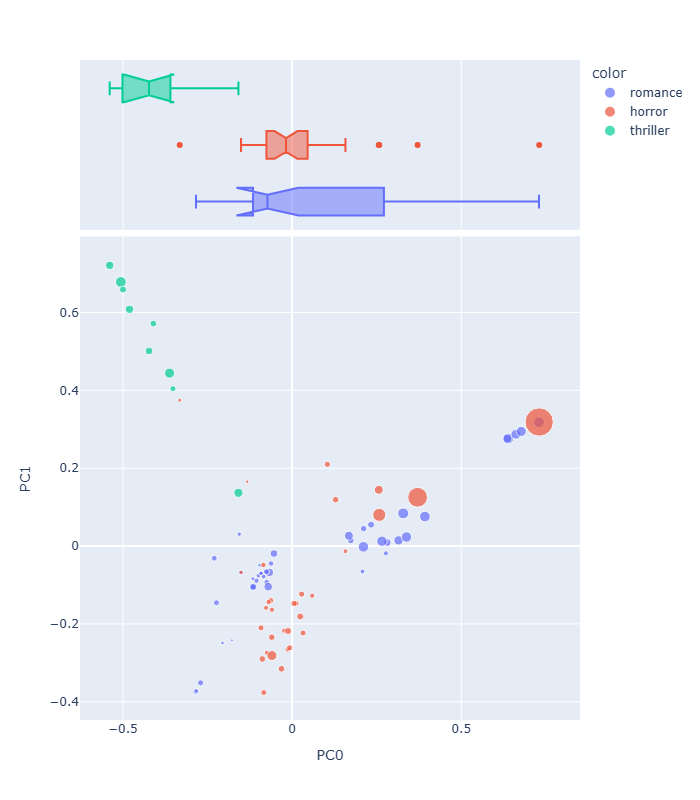

In [100]:
vis_pcs(DCM, 0, 1)